# Credit Card Fraud Detection Using Machine Learning

## Detecting Fraudulent Transactions through Predictive Analytics

**Author:** Che Francis

**Project Type:** Binary Classification

**Dataset:** European Credit Card Transactions (September 2013)

**Tools Used:** Python, Pandas, NumPy, Matplotlib, Seaborn, Scikit-learn

---

## Project Overview

Credit card fraud continues to be one of the biggest challenges facing financial institutions worldwide. As digital transactions increase, traditional rule-based fraud detection systems struggle to identify increasingly sophisticated fraudulent behavior.

In this project, we develop and compare several machine learning models capable of identifying fraudulent credit card transactions. Given the highly imbalanced nature of the dataset, special attention is paid to handling class imbalance, selecting appropriate evaluation metrics, and optimizing model performance.

The final objective is to recommend a machine learning model that provides the best balance between detecting fraudulent transactions while minimizing false alarms.

# Project Objectives

The objectives of this project are:

- Understand the characteristics of the fraud detection dataset.
- Perform exploratory data analysis to identify important patterns.
- Prepare the data for machine learning.
- Build multiple classification models.
- Handle severe class imbalance using various sampling techniques.
- Tune model hyperparameters.
- Compare model performance using appropriate evaluation metrics.
- Recommend the best-performing model from a business perspective.

# 1. Business Understanding

Credit card fraud is one of the fastest-growing financial crimes globally. Every fraudulent transaction results in financial losses, operational costs, customer dissatisfaction, and reputational damage for financial institutions.

Traditional fraud detection systems often rely on predefined rules. However, fraud patterns continually evolve, making rule-based systems less effective over time.

Machine learning offers the ability to learn complex transaction patterns from historical data and detect suspicious behavior automatically.

The primary objective of this project is therefore to build a predictive machine learning model capable of distinguishing fraudulent transactions from legitimate ones.

A major challenge of this dataset is that fraudulent transactions account for only a very small percentage of all observations. This creates a severe class imbalance that requires specialized preprocessing techniques and evaluation metrics.

Rather than maximizing overall accuracy, the focus of this project is to maximize the model's ability to correctly identify fraudulent transactions while minimizing false positives.

# 2. Data Understanding

Before building predictive models, it is important to understand the structure and quality of the dataset.

This section answers several important questions:

- How many observations are available?
- How many variables are included?
- Are there missing values?
- Are there duplicate observations?
- What are the data types?
- What does each feature represent?

Understanding the dataset helps identify potential quality issues before moving into exploratory analysis and model development.

In [1]:
# Import Required Libraries

# Data Manipulation
import numpy as np
import pandas as pd

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

# Plot settings
plt.style.use("ggplot")
sns.set_theme(style="whitegrid")


# Display plots inline
%matplotlib inline

In [2]:
# Load Dataset

df = pd.read_csv("../data/creditcard.csv")

# Display first five observations
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [3]:
# Dataset Dimensions

print(f"Number of Rows: {df.shape[0]:,}")
print(f"Number of Columns: {df.shape[1]}")

Number of Rows: 284,807
Number of Columns: 31


In [4]:
# Dataset Information 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [5]:
# Missing Values

missing_values = df.isnull().sum()

missing_values


Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [6]:
# Duplicate Records

duplicates = df.duplicated().sum()
print(f"Number of Duplicate Records: {duplicates:,}")

Number of Duplicate Records: 1,081


In [7]:
# Summary Statistics

df.describe().T


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995


## Business Insight

## Key Takeaways

From the initial inspection, we observe that:

- The dataset contains over 284,000 credit card transactions.
- All variables are numerical.
- No missing values are present.
- The target variable (`Class`) is binary.
- Most predictor variables have already been transformed using Principal Component Analysis (PCA).
- The `Amount` and `Time` variables remain in their original form and may require additional preprocessing.

# Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is an essential step in every machine learning project. It enables us to understand the underlying structure of the data, identify patterns, detect anomalies, and uncover relationships between variables before model development.

The objectives of this section are to:

- Understand the distribution of fraudulent and legitimate transactions.
- Explore the transaction amount and transaction time features.
- Investigate feature correlations.
- Detect skewness and potential outliers.
- Generate insights that will guide preprocessing and model selection.

The findings from this analysis will influence subsequent steps such as feature engineering, handling class imbalance, and model evaluation.

In [8]:
# Class Distribution 

class_counts = df["Class"].value_counts()

class_counts

Class
0    284315
1       492
Name: count, dtype: int64

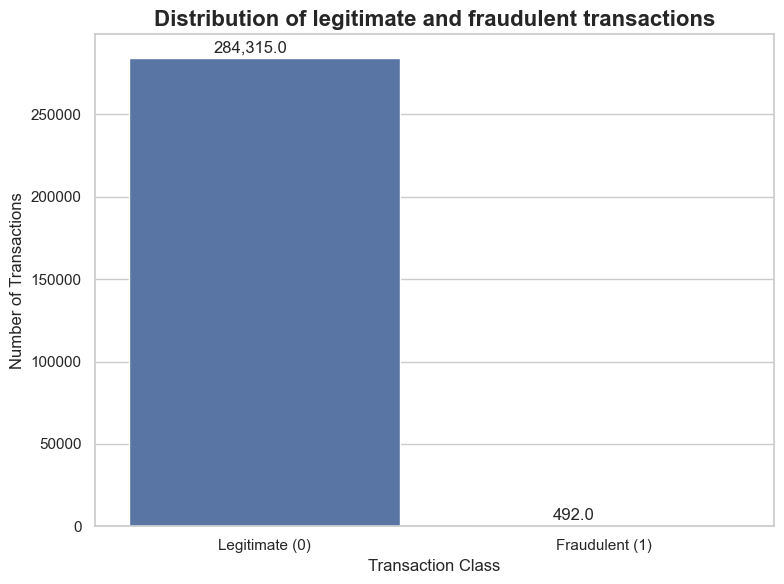

In [9]:
# Visualize Class Distribution

plt.figure(figsize=(8, 6))
colors = ["#4C72B0", "#DD8452"]
ax = sns.countplot(x="Class", data=df, palette=colors)

plt.title(
    "Distribution of legitimate and fraudulent transactions", fontsize=16, 
    fontweight="bold"
)
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

ax.set_xticklabels(["Legitimate (0)", "Fraudulent (1)"])

# Display values above each bar
for p in ax.patches:
    ax.annotate(
        f"{p.get_height():,}", 
        (p.get_x()+0.25, p.get_height()+3000), 
        fontsize=12,
    )
plt.tight_layout()
plt.show()

### Interpretation

The visualization clearly demonstrates that the dataset is highly imbalanced.

Out of more than **284,000 transactions**, only **492** are fraudulent, representing approximately **0.17%** of the total observations.

This is a common characteristic of fraud detection problems where fraudulent activities are naturally rare.

Such imbalance presents a challenge because a model can achieve very high accuracy simply by predicting every transaction as legitimate. Therefore, accuracy alone will not be an appropriate evaluation metric for this project.

Instead, metrics such as **Precision**, **Recall**, **F1-Score**, and **ROC-AUC** will provide a more reliable assessment of model performance.

In [10]:
# Percentage Distribution


percentage = (
    df["Class"]
    .value_counts(normalize=True)
    *100
).round(3)

percentage

Class
0    99.827
1     0.173
Name: proportion, dtype: float64

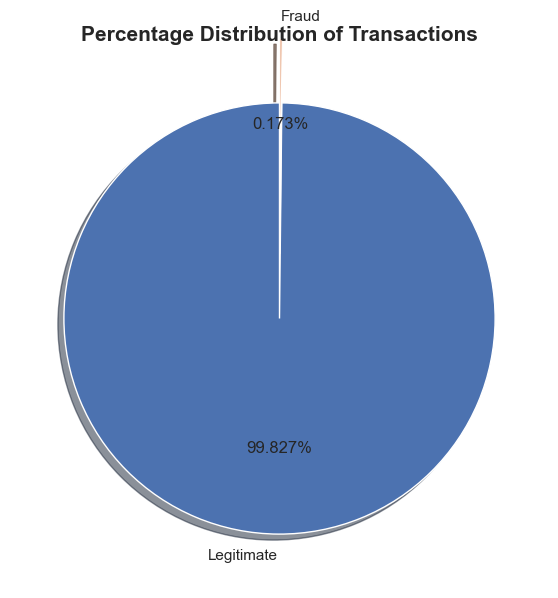

In [11]:
plt.figure(figsize=(7,7))

explode = (0,0.3)

plt.pie(
    percentage,
    labels=["Legitimate","Fraud"],
    autopct="%1.3f%%",
    colors=["#4C72B0","#DD8452"],
    explode=explode,
    startangle=90,
    shadow=True
)

plt.title(
    "Percentage Distribution of Transactions",
    fontsize=15,
    fontweight="bold"
)

plt.show()

### Business Insight

Although fraudulent transactions account for only a very small proportion of all transactions, they represent the transactions with the greatest financial impact.

This imbalance reinforces the importance of designing models that prioritize detecting fraudulent cases without generating an excessive number of false alarms.


In [12]:
# Summary Statistics for Amount

df["Amount"].describe()

count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

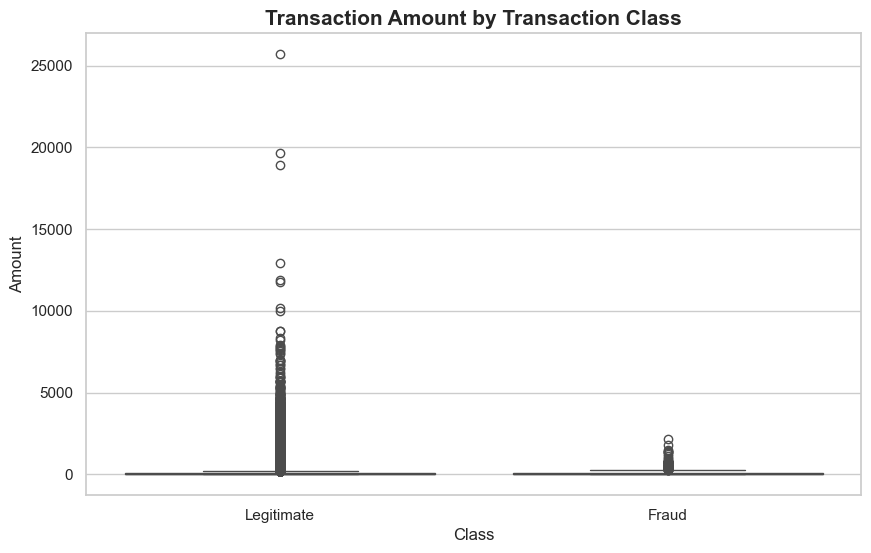

In [13]:
# Fraud vs Amount Visualization

plt.figure(figsize=(10,6))

sns.boxplot(
    x="Class",
    y="Amount",
    data=df,
    palette=["#4C72B0","#DD8452"]
)

plt.xticks(
    [0,1],
    ["Legitimate","Fraud"]
)

plt.title(
    "Transaction Amount by Transaction Class",
    fontsize=15,
    fontweight="bold"
)

plt.show()

### Interpretation

Fraudulent transactions are not exclusively associated with large transaction amounts.

Fraud occurs across a wide range of transaction values.

This suggests that transaction amount alone is unlikely to provide sufficient discriminatory power for fraud detection and should be combined with other predictive features.

## Exploratory Data Analysis (EDA Part 2)

In this section, we explore additional characteristics of fraudulent transactions, including:

- Transaction time patterns
- Correlation between variables
- Feature distributions
- Outlier detection
- Business insights

Understanding these relationships helps identify behavioural differences between fraudulent and legitimate transactions.

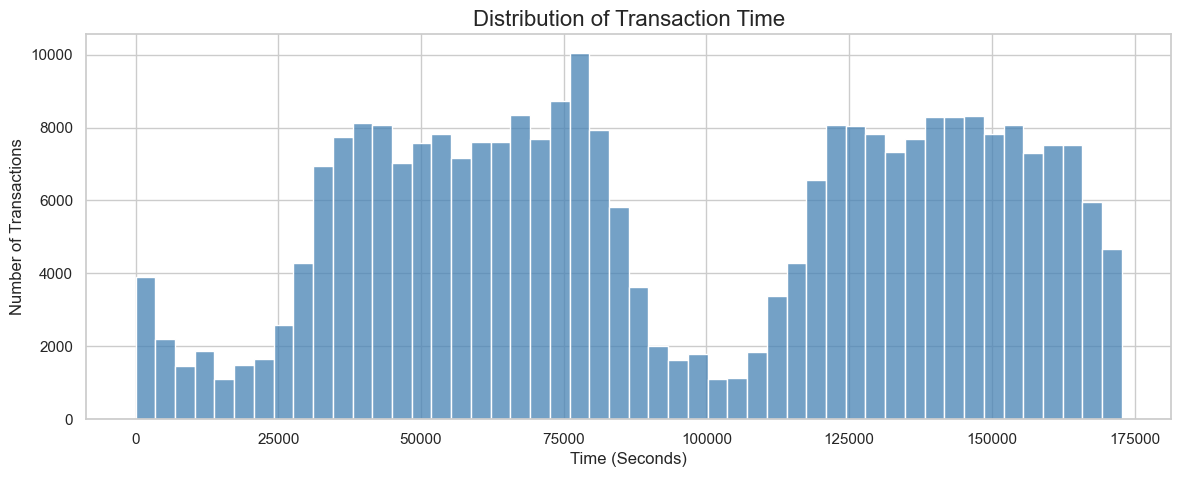

In [14]:
# Time distribution of Transactions
# (Seconds elapsed since the first recorded transaction.)

plt.figure(figsize=(14,5))

sns.histplot(df["Time"], bins=50, color="steelblue")

plt.title("Distribution of Transaction Time", fontsize=16)
plt.xlabel("Time (Seconds)")
plt.ylabel("Number of Transactions")

plt.show()

### Business Insight

The transaction time distribution illustrates how transaction activity changes throughout the observation period.

If transaction activity is concentrated within certain periods, fraud monitoring systems may require adaptive thresholds rather than static rules.

Time itself may become a useful predictive feature when combined with other transaction characteristics.

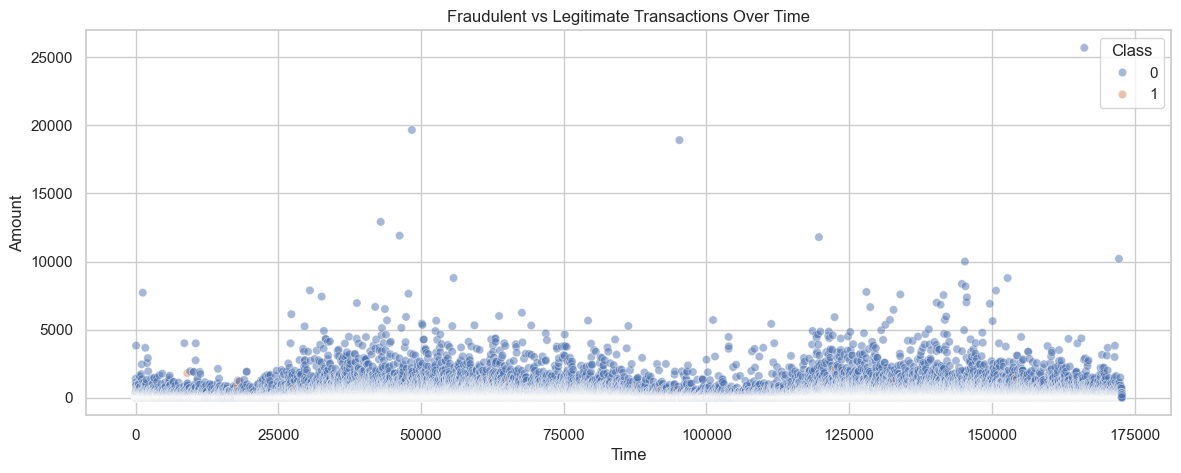

In [15]:
# Fraud accross time

plt.figure(figsize=(14,5))

sns.scatterplot(
    data=df,
    x="Time",
    y="Amount",
    hue="Class",
    alpha=0.5
)

plt.title("Fraudulent vs Legitimate Transactions Over Time")

plt.show()

## Correlation Analysis
Identifying relationships between variables, detect redundancy, understand which features are associated with the target variable, and guide feature engineering.
Correlation analysis helps us understand how variables relate to one another and, more importantly, how they relate to fraudulent transactions.

A positive correlation means two variables tend to increase together.

A negative correlation means that as one increases, the other decreases.

Understanding these relationships provides valuable insights into patterns associated with fraud.

In [16]:
# compute correlations
correlation_matrix = df.corr(numeric_only=True)

correlation_matrix.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
Time,1.000000,1.173963e-01,-1.059333e-02,-4.196182e-01,-1.052602e-01,1.730721e-01,-6.301647e-02,8.471437e-02,-3.694943e-02,-8.660434e-03,...,4.473573e-02,1.440591e-01,5.114236e-02,-1.618187e-02,-2.330828e-01,-4.140710e-02,-5.134591e-03,-9.412688e-03,-0.010596,-0.012323
V1,0.117396,1.000000e+00,4.135835e-16,-1.227819e-15,-9.215150e-16,1.812612e-17,-6.506567e-16,-1.005191e-15,-2.433822e-16,-1.513678e-16,...,-2.457409e-16,-4.290944e-16,6.168652e-16,-4.425156e-17,-9.605737e-16,-1.581290e-17,1.198124e-16,2.083082e-15,-0.227709,-0.101347
V2,-0.010593,4.135835e-16,1.000000e+00,3.243764e-16,-1.121065e-15,5.157519e-16,2.787346e-16,2.055934e-16,-5.377041e-17,1.978488e-17,...,-8.480447e-17,1.526333e-16,1.634231e-16,1.247925e-17,-4.478846e-16,2.057310e-16,-4.966953e-16,-5.093836e-16,-0.531409,0.091289
V3,-0.419618,-1.227819e-15,3.243764e-16,1.000000e+00,4.711293e-16,-6.539009e-17,1.627627e-15,4.895305e-16,-1.268779e-15,5.568367e-16,...,5.706192e-17,-1.133902e-15,-4.983035e-16,2.686834e-19,-1.104734e-15,-1.238062e-16,1.045747e-15,9.775546e-16,-0.210880,-0.192961
V4,-0.105260,-9.215150e-16,-1.121065e-15,4.711293e-16,1.000000e+00,-1.719944e-15,-7.491959e-16,-4.104503e-16,5.697192e-16,6.923247e-16,...,-1.949553e-16,-6.276051e-17,9.164206e-17,1.584638e-16,6.070716e-16,-4.247268e-16,3.977061e-17,-2.761403e-18,0.098732,0.133447


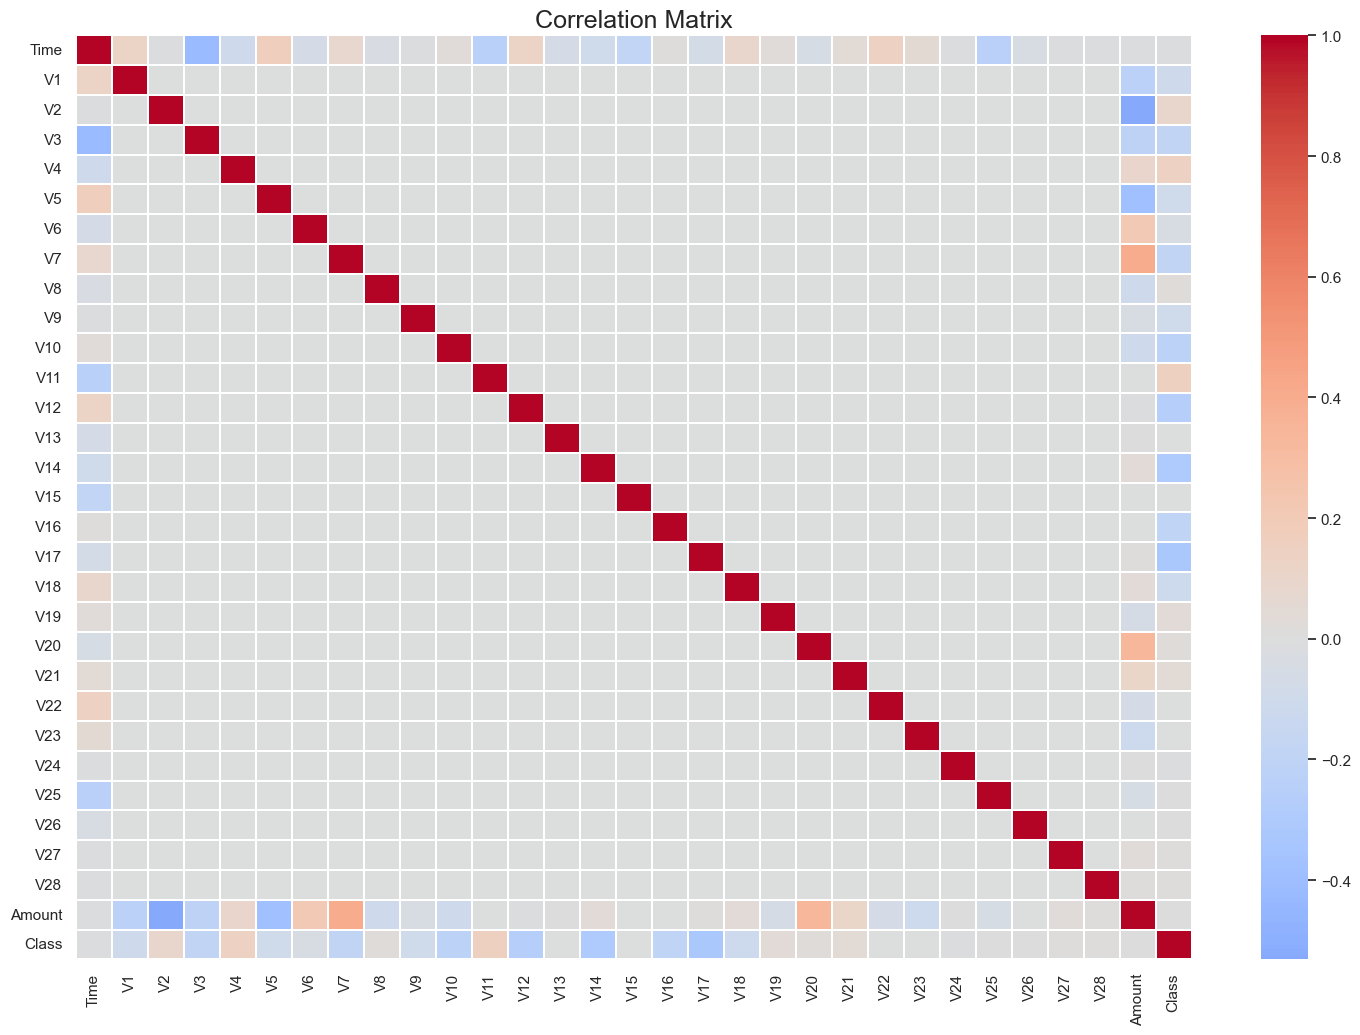

In [17]:
# Heatmap of Correlation Matrix

plt.figure(figsize=(18,12))

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Correlation Matrix", fontsize=18)

plt.show()


In [18]:
# correlation with fraud

fraud_corr = correlation_matrix["Class"].sort_values(ascending=False)

fraud_corr

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

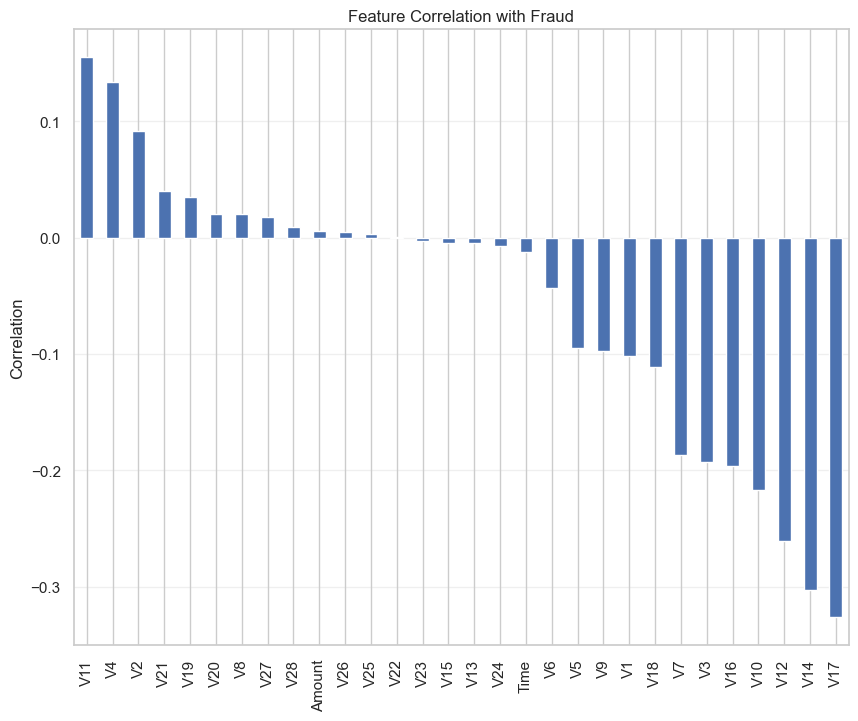

In [19]:
# visualize top features correlated with fraud

top_corr = fraud_corr.drop("Class")

plt.figure(figsize=(10,8))

top_corr.plot(kind="bar")

plt.title("Feature Correlation with Fraud")
plt.ylabel("Correlation")

plt.grid(axis="y", alpha=0.3)

plt.show()

### Business Interpretation

Most variables exhibit relatively weak linear correlations with fraud, indicating that fraudulent behaviour is complex and cannot be explained by a single feature.

This suggests that machine learning models capable of capturing nonlinear relationships and interactions between multiple variables are likely to outperform simple linear models.

The strongest positively and negatively correlated variables deserve further investigation during feature importance analysis.

## Feature Distribution
### Distribution of Key Features

This section compares the distributions of selected features between legitimate and fraudulent transactions.

Differences in these distributions help identify variables that may contribute significantly to fraud detection.

In [20]:
important_features = [
    "V1",
    "V2",
    "V3",
    "V4",
    "V10",
    "V11",
    "V12",
    "V14",
    "V16",
    "V17"
]

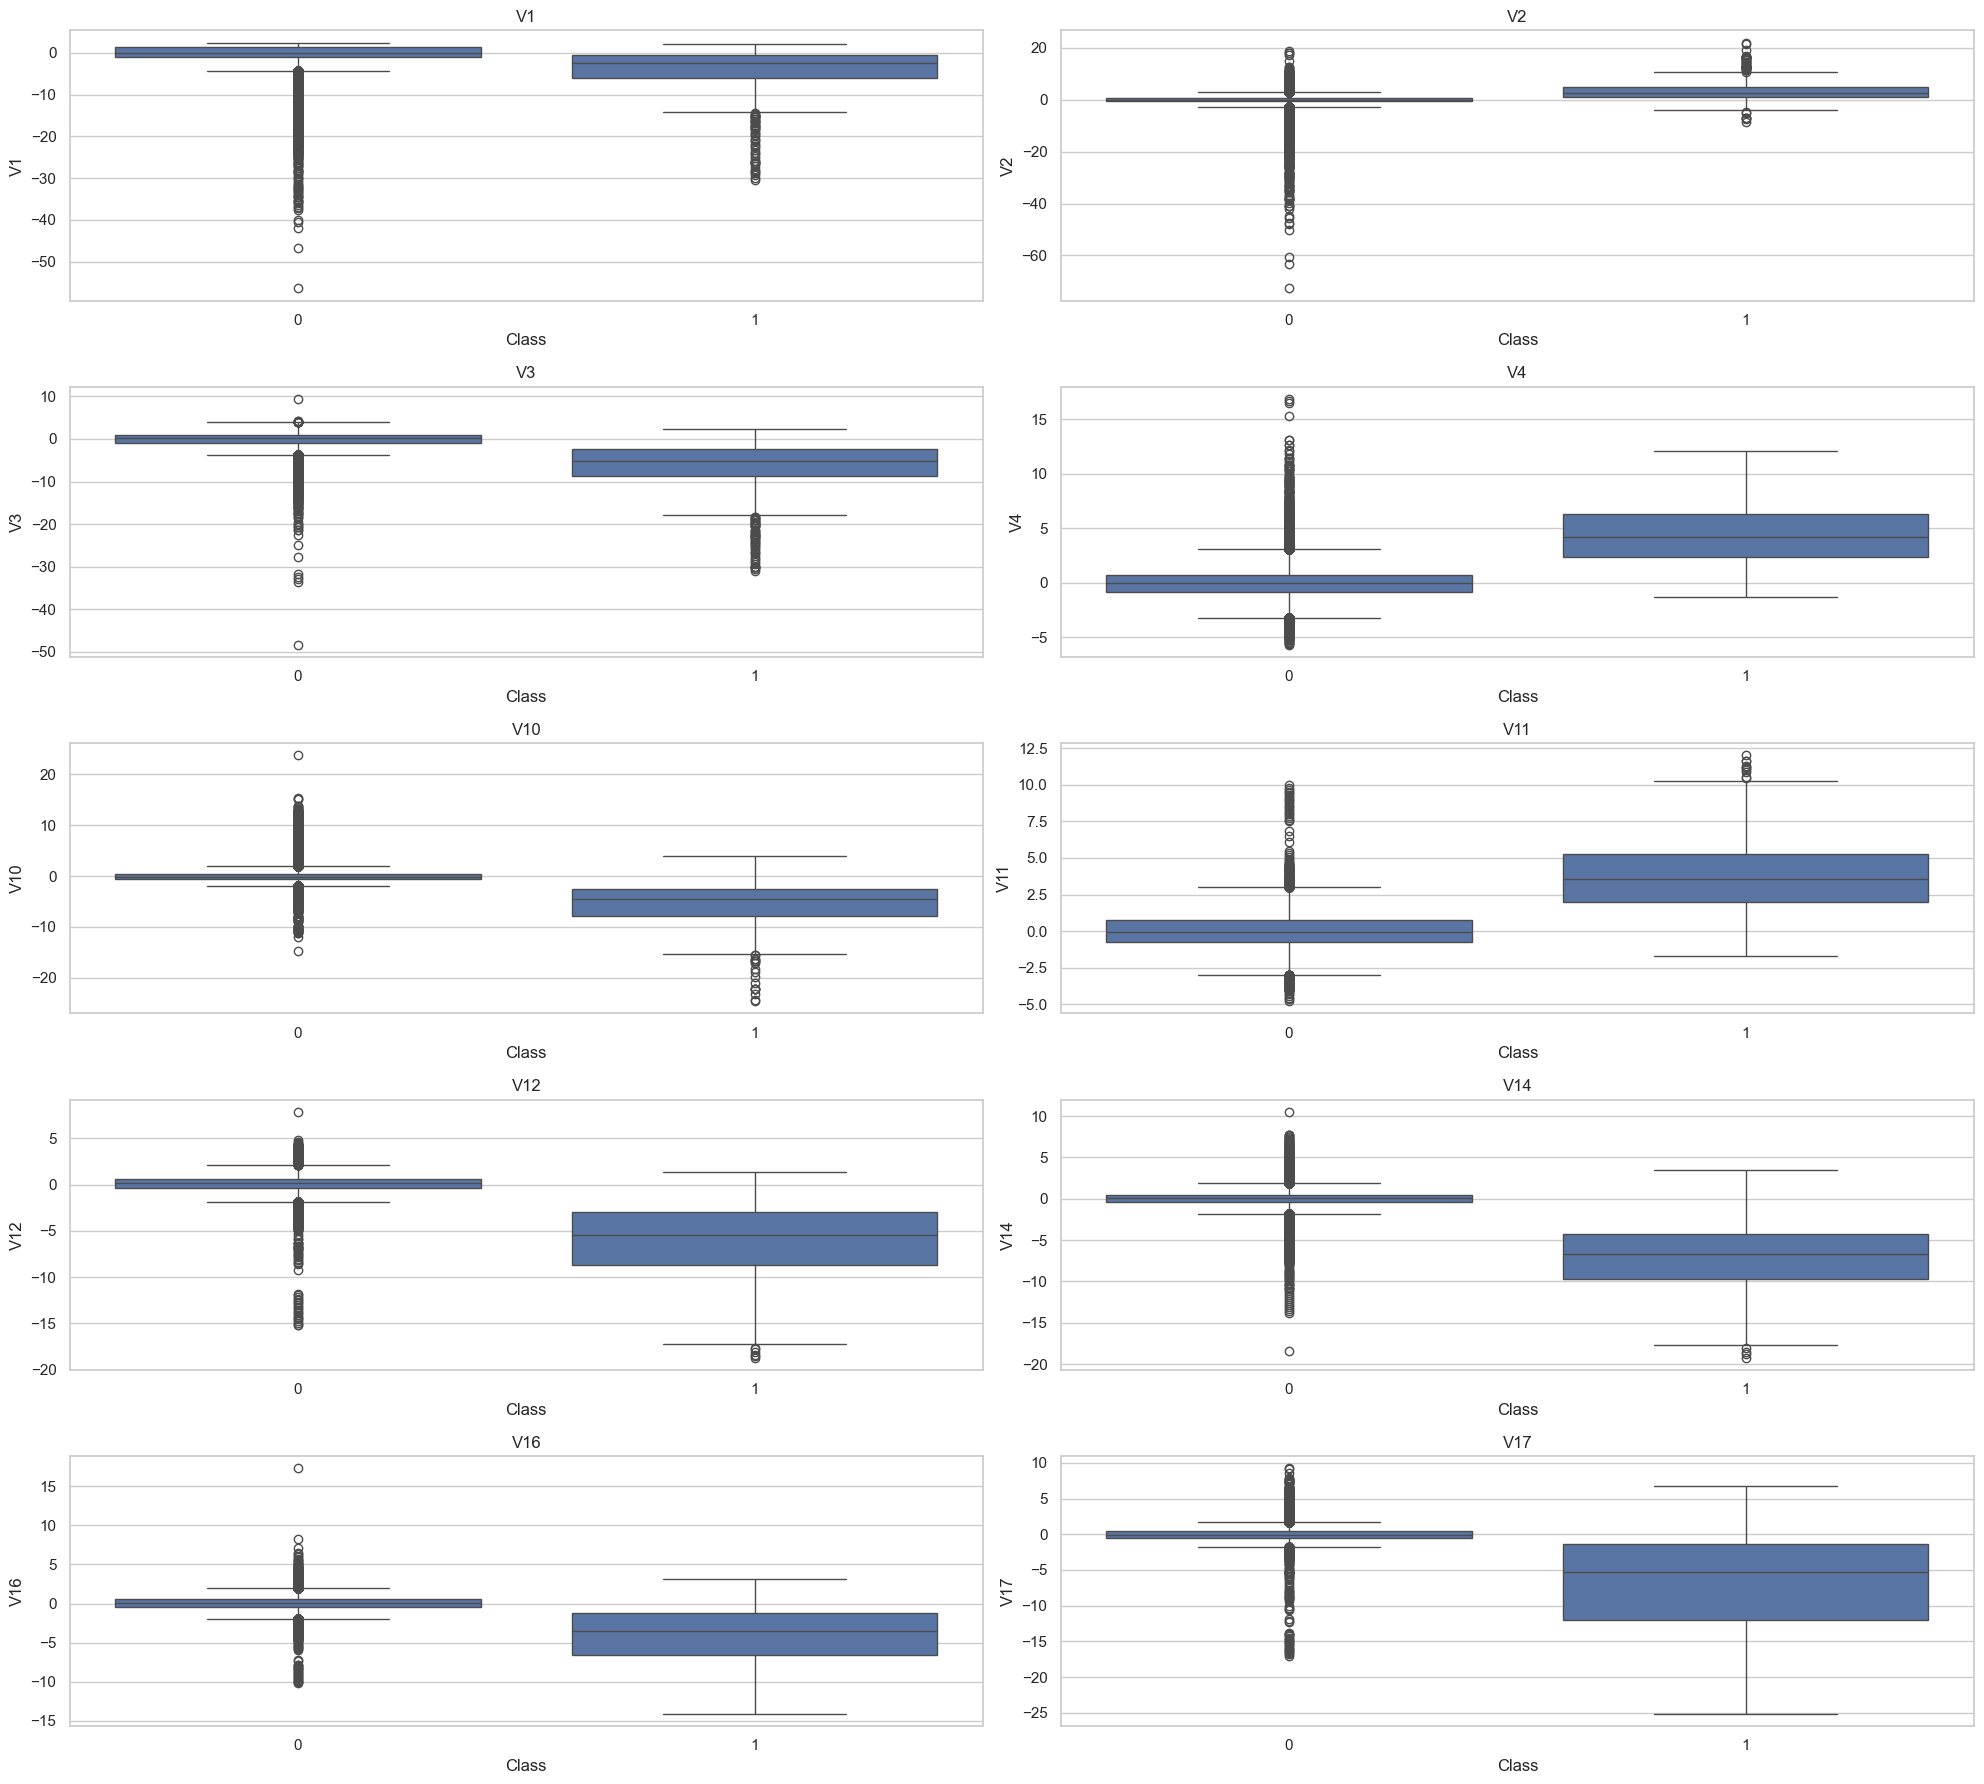

In [21]:
# visualize features
plt.figure(figsize=(20,18))

for i, feature in enumerate(important_features):

    plt.subplot(5,2,i+1)

    sns.boxplot(
        data=df,
        x="Class",
        y=feature
    )

    plt.title(feature)

plt.tight_layout()

plt.show()

### Business Interpretation

Several variables display noticeably different distributions between fraudulent and legitimate transactions.

These differences suggest that fraudulent behaviour follows identifiable patterns that machine learning algorithms can exploit for classification.

Features with clear separation between classes are likely to contribute significantly to predictive performance.

## Outlier Analysis

Outliers are observations that differ substantially from the majority of the data.

In many machine learning projects, outliers are removed to improve model performance.

However, in fraud detection, extreme observations may represent genuine fraudulent behaviour and therefore require careful interpretation rather than automatic removal.

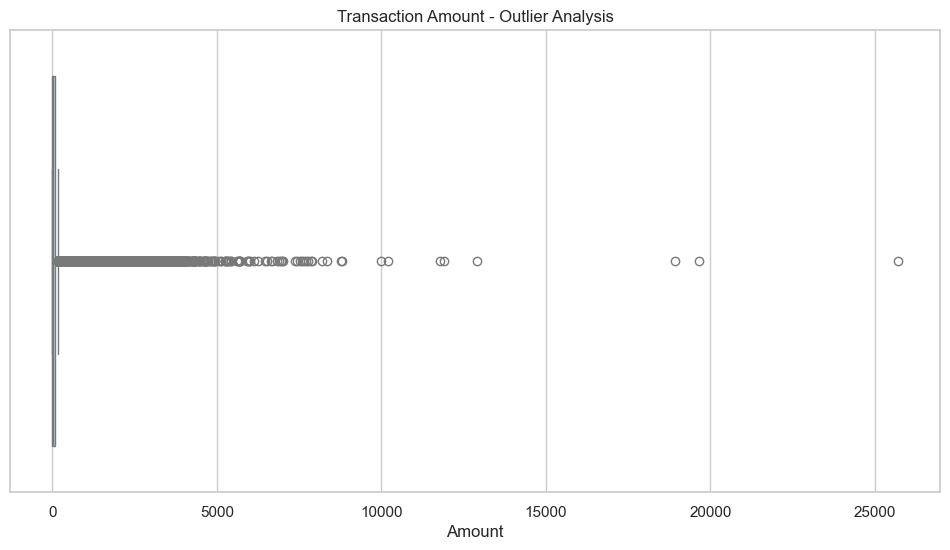

In [22]:
# examine transaction amount
plt.figure(figsize=(12,6))

sns.boxplot(
    x=df["Amount"],
    color="lightblue"
)

plt.title("Transaction Amount - Outlier Analysis")

plt.show()

In [23]:
# quantify outliers in transaction amount
Q1 = df["Amount"].quantile(0.25)

Q3 = df["Amount"].quantile(0.75)

IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR

upper_bound = Q3 + 1.5 * IQR

outliers = df[
    (df["Amount"] < lower_bound) |
    (df["Amount"] > upper_bound)
]

print(f"Number of outliers: {len(outliers)}")
print(f"Percentage of dataset: {(len(outliers)/len(df))*100:.2f}%")

Number of outliers: 31904
Percentage of dataset: 11.20%


### Business Interpretation

The transaction amount contains a substantial number of statistical outliers.

Unlike many predictive modelling problems, these observations should not automatically be removed because unusually large or unusual transactions may represent genuine fraudulent activity.

Instead, they provide valuable information that can improve the model's ability to detect suspicious behaviour.

## Fraud Pattern Analysis

The objective of this section is to identify behavioural differences between fraudulent and legitimate transactions.

Rather than examining individual variables in isolation, we analyse how fraudulent transactions differ in terms of transaction amounts, feature distributions, and overall patterns.

These insights provide business value by helping financial institutions understand suspicious behaviour and improve fraud detection strategies.

In [24]:
amount_summary = df.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "min", "max", "std"]
)

amount_summary

,count,mean,median,min,max,std
Class,,,,,,
0,284315,88.291022,22.00,0.0,25691.16,250.105092
1,492,122.211321,9.25,0.0,2125.87,256.683288


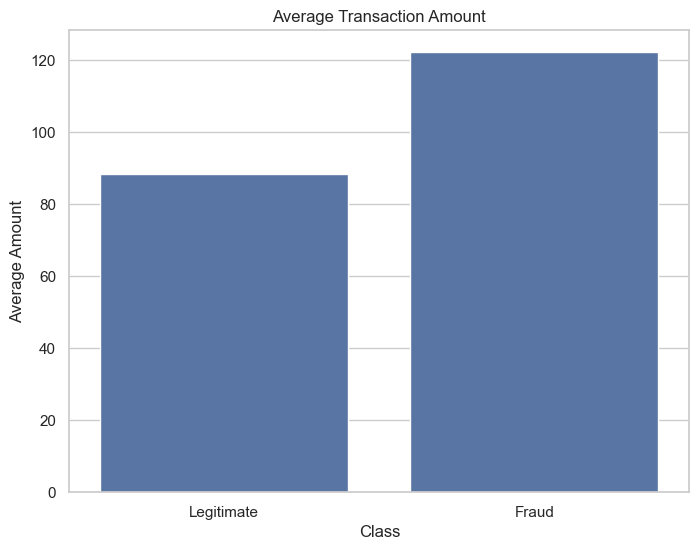

In [25]:
# visualize amount_summary

plt.figure(figsize=(8,6))

sns.barplot(
    data=df,
    x="Class",
    y="Amount",
    estimator=np.mean,
    errorbar=None
)

plt.xticks([0,1],["Legitimate","Fraud"])

plt.title("Average Transaction Amount")

plt.ylabel("Average Amount")

plt.show()

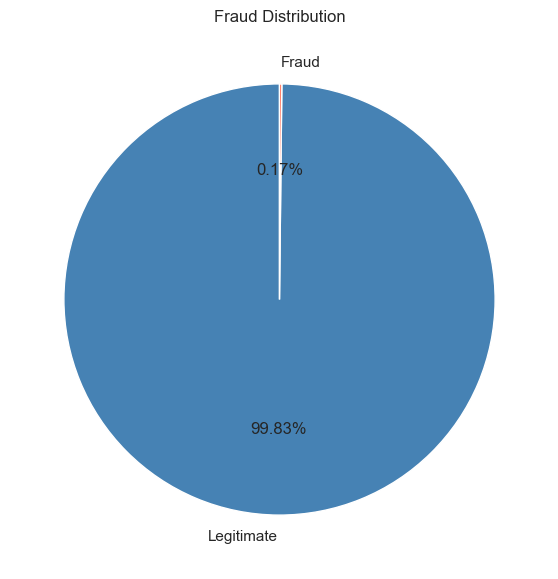

In [26]:
# Show Fraud Percentage

fraud_counts = df["Class"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    fraud_counts,
    labels=["Legitimate","Fraud"],
    autopct="%1.2f%%",
    startangle=90,
    colors=["steelblue","tomato"]
)

plt.title("Fraud Distribution")

plt.show()

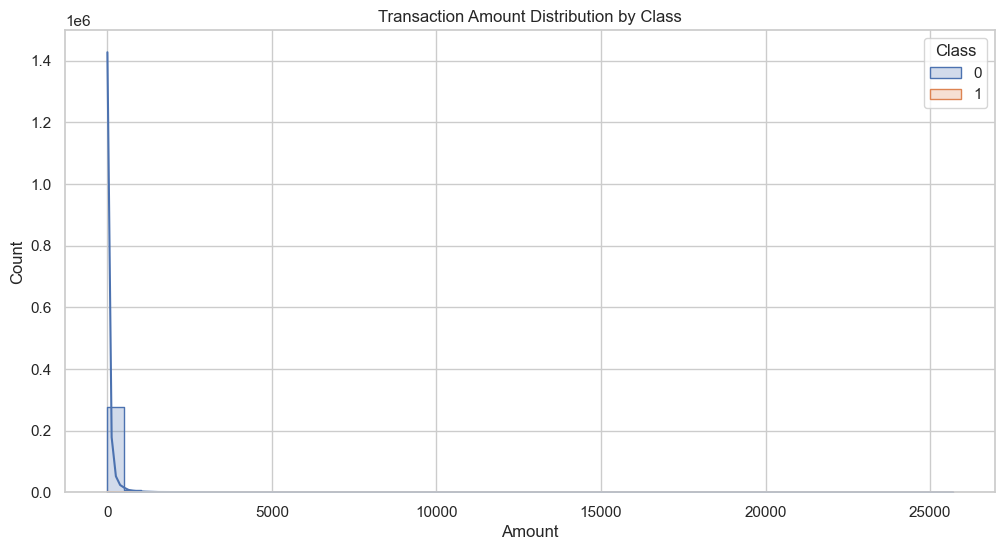

In [27]:
# Show Amount Distribution by Class

plt.figure(figsize=(12,6))

sns.histplot(
    data=df,
    x="Amount",
    hue="Class",
    bins=50,
    kde=True,
    element="step"
)

plt.title("Transaction Amount Distribution by Class")

plt.show()

### Business Interpretation

Fraudulent transactions do not occur exclusively among high-value transactions.

Instead, fraudulent behaviour spans a range of transaction amounts, demonstrating that transaction amount alone is insufficient for fraud detection.

Effective fraud detection requires combining multiple behavioural indicators rather than relying on a single variable.

# EDA Summary (Key Findings)

The exploratory data analysis revealed several important characteristics of fraudulent transactions.

### Key Findings

1. The dataset is highly imbalanced, with fraudulent transactions representing only a very small proportion of all transactions.

2. Fraudulent transactions exhibit behavioural patterns that differ from legitimate transactions across multiple variables.

3. Several PCA-transformed features demonstrate noticeable separation between fraudulent and legitimate classes, suggesting that they contain useful predictive information.

4. Transaction amount alone is insufficient for distinguishing fraud, indicating that multiple variables must be considered simultaneously.

5. Transaction amounts contain many statistical outliers; however, these observations may represent genuine fraudulent activity and should be interpreted carefully rather than removed automatically.

6. Correlation analysis suggests that fraud detection requires learning complex relationships between variables rather than relying on individual predictors.

## Business Insights & Recommendations

The exploratory data analysis provides several practical recommendations that financial institutions can implement to strengthen fraud detection and reduce financial losses.

The following recommendations are supported by the evidence obtained during exploratory data analysis.

## Recommendation 1: Implement an Automated Machine Learning Fraud Detection System

The exploratory analysis demonstrated that fraudulent behaviour depends on multiple interacting variables rather than a single transaction characteristic.

Traditional rule-based systems may fail to capture these complex relationships.

A supervised machine learning model should therefore be deployed to evaluate transactions in real time and assign a fraud risk score.

## Recommendation 2: Prioritize High-Risk Transactions

Because fraudulent transactions represent only a very small percentage of the overall transaction volume, manually reviewing every transaction would be operationally inefficient.

Instead, investigators should focus their attention on transactions identified by the model as high risk.

## Recommendation 3: Improve Fraud Data Collection

The bank should continue collecting and maintaining detailed records of confirmed fraudulent transactions.

A larger and more representative fraud dataset will improve future machine learning models by exposing them to a wider variety of fraudulent behaviours.

## Recommendation 4: Continuously Retrain the Detection Model

Fraud strategies evolve over time.

The fraud detection model should therefore be retrained periodically using newly confirmed fraud cases to maintain predictive performance and adapt to emerging fraud patterns.





# Part 2: Feature Engineering & Data Preparation

## Data Preparation

The objective of this phase is to prepare the dataset for machine learning.

Before training any predictive models, it is important to assess data quality, identify potential issues, and ensure that the dataset is suitable for modelling.

This includes checking for:

- Missing values
- Duplicate records
- Data types
- Feature distributions
- Class imbalance

In [28]:
# Check for missing values
missing_values = df.isnull().sum()

missing_summary = (
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
)

print(f"Total missing values: {missing_values.sum()}")

missing_summary

Total missing values: 0


Series([], dtype: int64)

In [29]:
# data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

In [30]:
# duplicate records 
duplicates = df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 1081


## Feature Engineering

Feature engineering is the process of creating, transforming, or selecting variables that improve the predictive performance of machine learning models.

Well-designed features help machine learning algorithms better capture the underlying patterns within the data and often contribute more to model performance than the choice of algorithm itself.

In [31]:
# log transaction amount
import numpy as np

df["Log_Amount"] = np.log1p(df["Amount"])

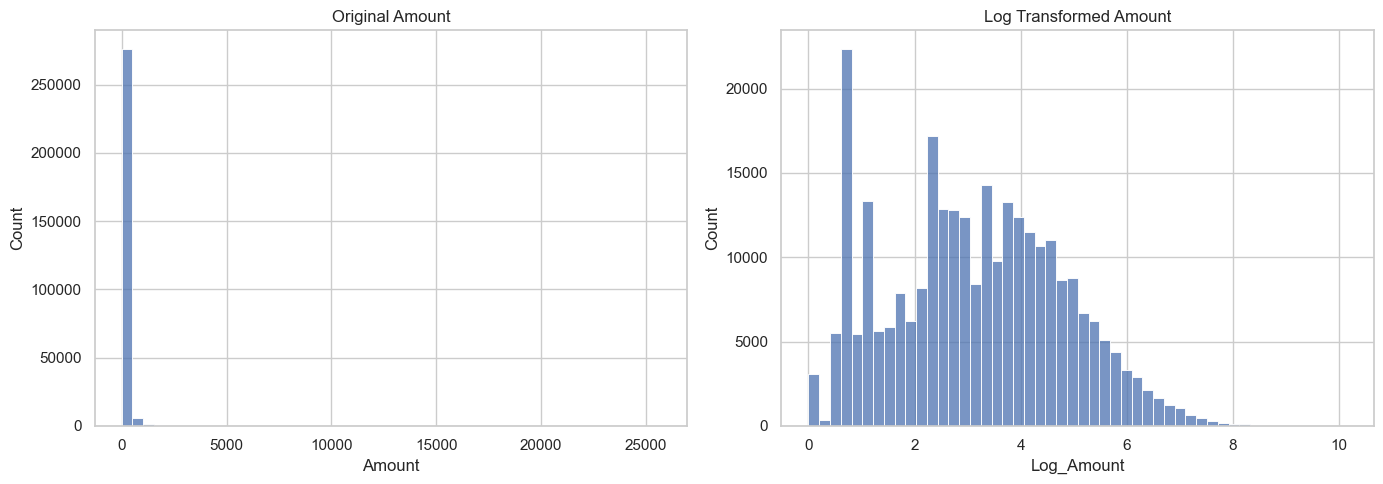

In [32]:
# compare data before and after log transformation

plt.figure(figsize=(14,5))

plt.subplot(1,2,1)
sns.histplot(df["Amount"], bins=50)
plt.title("Original Amount")

plt.subplot(1,2,2)
sns.histplot(df["Log_Amount"], bins=50)
plt.title("Log Transformed Amount")

plt.tight_layout()

plt.show()

### Business Interpretation

The logarithmic transformation reduces the extreme skewness observed in transaction amounts while preserving the relative ordering of transactions.

This transformation can improve the performance of machine learning models that are sensitive to highly skewed numerical features.

# Train-Test Split

Before training any machine learning model, the dataset is divided into separate training and testing subsets.

This ensures that model performance is evaluated on previously unseen data, providing a realistic estimate of how the model will perform in production.

The target variable is separated from the predictor variables before splitting the data.

In [33]:
# Features
X = df.drop("Class", axis=1)

# Target
y = df["Class"]

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

Feature Matrix Shape: (284807, 31)
Target Shape: (284807,)


In [34]:
#train-test split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

### Feature Scaling

Feature scaling standardizes numerical variables so that they contribute equally during model training.

Algorithms such as Logistic Regression, Support Vector Machines and K-Nearest Neighbors are sensitive to differences in feature magnitudes. Therefore, feature scaling is applied before training these models.

To avoid data leakage, the scaler is fitted only on the training data and then applied to both the training and testing datasets.

In [35]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

In [36]:
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Training Shape:", X_train_scaled.shape)

print("Testing Shape:", X_test_scaled.shape)

Training Shape: (227845, 31)
Testing Shape: (56962, 31)


### Interpretation

Feature scaling ensures that variables measured on different numerical ranges contribute equally during model training.

The scaler was fitted exclusively on the training data to prevent information from the testing dataset influencing the learning process, thereby avoiding data leakage.

# Baseline Model - Logistic Regression

Logistic Regression is selected as the baseline classification model.

Although it is a relatively simple algorithm, it provides an excellent benchmark against which more sophisticated models can be compared.

Its interpretability, computational efficiency and strong performance on many binary classification problems make it an appropriate starting point for fraud detection.

In [37]:
# import model 

from sklearn.linear_model import LogisticRegression

In [38]:
# create model 

log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000
)

In [39]:
# Model Training 

log_reg.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [40]:
# Make predictions on the test set

y_pred = log_reg.predict(X_test_scaled)



In [41]:
# Predicting probabilities for the positive class (fraudulent transactions)

y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]


In [42]:
# Model verification

print("Training completed successfully!")

print("Predictions:", len(y_pred))

print("Probability Predictions:", len(y_prob))

Training completed successfully!
Predictions: 56962
Probability Predictions: 56962


# Model Evaluation

After training the Logistic Regression model, its performance is evaluated using multiple classification metrics.

Since the fraud detection dataset is highly imbalanced, relying solely on accuracy may produce misleading conclusions.

Therefore, additional evaluation metrics including the confusion matrix, precision, recall, F1-score, and ROC-AUC are used to assess model performance.

In [43]:
# import metrics for evaluation

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    accuracy_score,
    roc_auc_score,
    ConfusionMatrixDisplay
)

In [44]:
# calculate accuracy 

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.9992


In [45]:
# classification report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.65      0.73        98

    accuracy                           1.00     56962
   macro avg       0.92      0.83      0.87     56962
weighted avg       1.00      1.00      1.00     56962



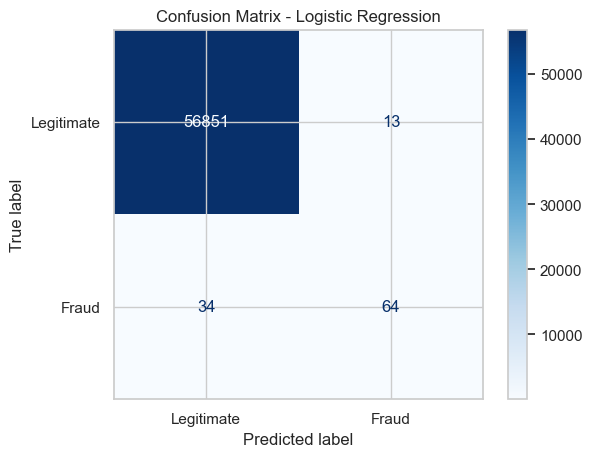

In [46]:
#confusion matrix   

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

In [47]:
# ROC AUC Score 

roc_auc = roc_auc_score(y_test, y_prob)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9599


## Logistic Regression Results

The Logistic Regression model achieved an overall accuracy of **99.92%** and an ROC-AUC score of **0.9599**, indicating strong discrimination between fraudulent and legitimate transactions.

For the fraud class, the model achieved:

- Precision: **0.83**
- Recall: **0.65**
- F1-score: **0.73**

The confusion matrix shows that only **13 legitimate transactions** were incorrectly classified as fraud, demonstrating a very low false positive rate.

However, the model failed to detect **34 fraudulent transactions**, indicating that approximately **35% of fraud cases were missed**.

From a business perspective, the model provides a strong baseline but would benefit from improved recall before deployment in a production fraud detection system.

# Decision Tree Classifier

A Decision Tree classifier is trained as the second baseline model.

Unlike Logistic Regression, Decision Trees can learn nonlinear relationships and interactions between variables without requiring feature scaling.

This makes them particularly useful for identifying complex fraud patterns.

In [48]:
# import required libraries for model building

from sklearn.tree import DecisionTreeClassifier

In [49]:
# create decision tree model
decision_tree = DecisionTreeClassifier(
    random_state=42,   
)

In [50]:
# train the decision tree model
decision_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [51]:
# Make predictions on the test set using the decision tree model
y_pred_tree = decision_tree.predict(X_test)

y_prob_tree = decision_tree.predict_proba(X_test)[:, 1]

In [52]:
# Model evaluation for Decision Tree

print("Accuracy:", accuracy_score(y_test, y_pred_tree))

print("\nClassification Report")

print(classification_report(y_test, y_pred_tree))

Accuracy: 0.9991573329588147

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.76      0.74      0.75        98

    accuracy                           1.00     56962
   macro avg       0.88      0.87      0.88     56962
weighted avg       1.00      1.00      1.00     56962



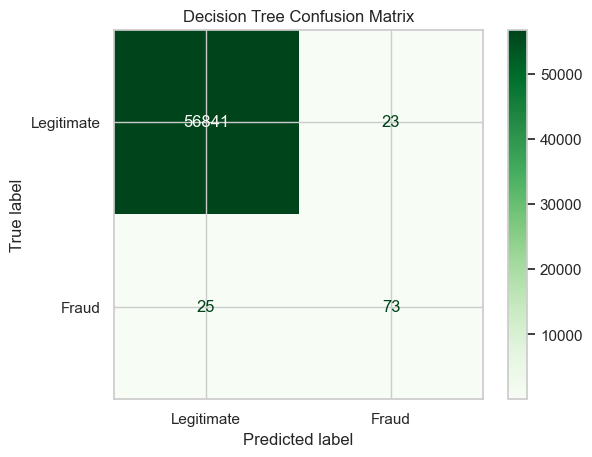

In [53]:
# confusion matrix for decision tree
cm = confusion_matrix(y_test, y_pred_tree)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)

disp.plot(cmap="Greens")

plt.title("Decision Tree Confusion Matrix")

plt.show()

In [54]:
# ROC AUC Score

roc_auc_tree = roc_auc_score(y_test, y_prob_tree)

print(f"ROC-AUC: {roc_auc_tree:.4f}")

ROC-AUC: 0.8722


## Decision Tree Results

The Decision Tree classifier achieved an overall accuracy of **99.92%**.

For the fraud class, the model achieved:

- Precision: **0.76**
- Recall: **0.74**
- F1-score: **0.75**
- ROC-AUC: **0.8722**

Compared with Logistic Regression, the Decision Tree detected more fraudulent transactions, increasing recall from **65% to 74%**.

However, this improvement came at the expense of a higher number of false positives, reducing precision from **83% to 76%**.

Overall, the Decision Tree demonstrates a stronger ability to detect fraud but produces more false alarms and lower probability discrimination, as reflected by its ROC-AUC score.

# Business Recommendation 

The Decision Tree provides improved fraud detection by identifying more fraudulent transactions than Logistic Regression. However, this improvement comes at the cost of additional false positives, which may increase the workload of fraud analysts and occasionally inconvenience legitimate customers. The choice between the two models therefore depends on whether the bank prioritizes maximizing fraud detection or minimizing customer disruption.

# Random Forest Classifier

Random Forest is an ensemble learning algorithm that combines the predictions of multiple decision trees to improve model performance and reduce overfitting.

Unlike a single Decision Tree, Random Forest builds multiple trees using different subsets of the training data and features. The final prediction is determined by majority voting across all trees.

This approach generally provides better generalization and more robust predictions on unseen data.

In [55]:
from sklearn.ensemble import RandomForestClassifier

In [56]:
# create random forest model

random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [57]:
# train the random forest model

random_forest.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [58]:
# Make predictions on the test set using the random forest model

y_pred_rf = random_forest.predict(X_test)
y_prob_rf = random_forest.predict_proba(X_test)[:, 1]

In [59]:
# evaluate the random forest model

print("Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report")

print(classification_report(y_test, y_pred_rf))

Accuracy: 0.9996137776061234

Classification Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.95      0.82      0.88        98

    accuracy                           1.00     56962
   macro avg       0.98      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962



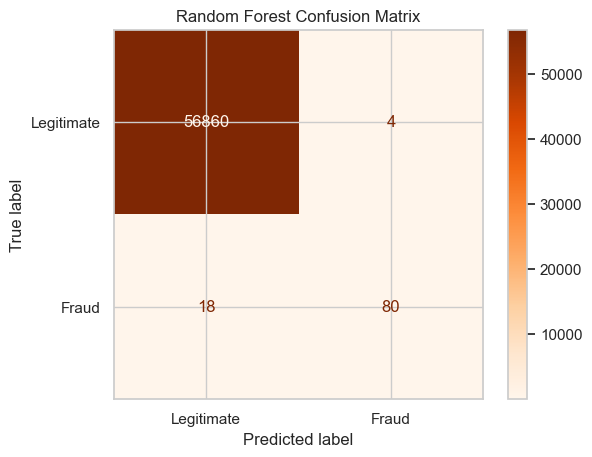

In [60]:
# confusion matrix for random forest
cm = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Legitimate", "Fraud"]
)
disp.plot(cmap="Oranges")
plt.title("Random Forest Confusion Matrix")
plt.show()



In [61]:
# ROC-AUC
roc_auc_rf = roc_auc_score(y_test, y_prob_rf)
print(f"ROC-AUC: {roc_auc_rf:.4f}")

ROC-AUC: 0.9528



## Model Comparison

| Metric    | Logistic Regression | Decision Tree | Random Forest |                Winner               |
| --------- | :-----------------: | :-----------: | :-----------: | :---------------------------------: |
| Accuracy  |      **99.92%**     |     99.92%    |   **99.96%**  |           🟢 Random Forest          |
| Precision |         0.83        |      0.76     |    **0.95**   |           🟢 Random Forest          |
| Recall    |         0.65        |      0.74     |    **0.82**   |           🟢 Random Forest          |
| F1-Score  |         0.73        |      0.75     |    **0.88**   |           🟢 Random Forest          |
| ROC-AUC   |      **0.9599**     |     0.8722    |     0.9528    | 🟢 Logistic Regression *(slightly)* |


## Random Forest Results

The Random Forest classifier achieved the strongest overall performance among the baseline models.

Performance metrics:

- Accuracy: **99.96%**
- Precision: **0.95**
- Recall: **0.82**
- F1-score: **0.88**
- ROC-AUC: **0.9528**

The confusion matrix shows that only **4 legitimate transactions** were incorrectly classified as fraud while **80 fraudulent transactions** were correctly detected.

Compared with Logistic Regression and Decision Tree, the Random Forest model substantially reduced both false positives and false negatives, demonstrating better generalization and a more balanced trade-off between fraud detection and customer experience.

Based on these baseline experiments, Random Forest is selected as the strongest candidate for further optimization.

#  Cross Validation

Cross-validation provides a more reliable estimate of model performance by repeatedly training and evaluating the model on different subsets of the training data.

Five-fold cross-validation is used to assess the stability and generalization performance of the Random Forest classifier.

In [62]:
from sklearn.model_selection import cross_val_score

In [63]:
# run cross-validation for Random Forest
cv_scores = cross_val_score(
    random_forest,
    X_train,
    y_train,
    cv=5,
    scoring="f1"
)

In [64]:
# Display cross-validation scores

print("Cross-Validation F1 Scores:", cv_scores)
print(f"Average F1 Score: {cv_scores.mean():.4f}")   
print (f"Standard Deviation of F1 Scores: {cv_scores.std():.4f}")

Cross-Validation F1 Scores: [0.82608696 0.86666667 0.83561644 0.84507042 0.85106383]
Average F1 Score: 0.8449
Standard Deviation of F1 Scores: 0.0138


## Cross-Validation Results

Five-fold cross-validation was performed to evaluate the robustness of the Random Forest classifier.

The model achieved an average F1-score of **0.8449** with a standard deviation of **0.0138**.

The low standard deviation indicates that the model performs consistently across different subsets of the training data, suggesting good generalization and reducing the likelihood that the observed performance is due to a favorable train-test split.

These results provide additional confidence that the Random Forest model is suitable for further optimization and potential deployment.

# Hyperparameter Tuning

To improve the performance of the Random Forest classifier, hyperparameter tuning is performed using GridSearchCV.

Grid Search evaluates multiple combinations of hyperparameter values using cross-validation and selects the combination that produces the best average performance.

This approach helps optimize the model while reducing the risk of overfitting.

In [65]:
from sklearn.model_selection import GridSearchCV

In [66]:
# define hyperparameter grid for Random Forest

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
}

In [67]:
# create GridSearchCV object for hyperparameter tuning

grid_search = GridSearchCV(
    estimator=random_forest,    
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

In [68]:
# fit the grid search to the training data
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_split': [2, 5],
                         'n_estimators': [100, 200]},
             scoring='f1')

In [69]:
# display best parameters and best score

print("Best Parameters:")

print(grid_search.best_params_)

print()

print("Best Cross-Validation F1 Score:")

print(f"{grid_search.best_score_:.4f}")

Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Best Cross-Validation F1 Score:
0.8478


### Hyperparameter Tuning Results

GridSearchCV was used to optimize the Random Forest classifier.

The best-performing hyperparameters were:

- Number of Trees: **200**
- Maximum Depth: **None**
- Minimum Samples Split: **2**

The optimized model achieved a mean cross-validation F1-score of **0.8478**, representing a modest improvement over the baseline Random Forest model.

These results indicate that the default Random Forest configuration was already performing well, and hyperparameter tuning provided a small but measurable improvement in model performance.

In [70]:
# retrieve the best estimator from the grid search
best_rf = grid_search.best_estimator_

In [71]:
# evaluate model again on the test set using the best estimator
y_pred_best = best_rf.predict(X_test)

y_prob_best = best_rf.predict_proba(X_test)[:, 1]

In [72]:
# display evaluation metrics for the best model

print(accuracy_score(y_test, y_pred_best))

print(classification_report(y_test, y_pred_best))

print(confusion_matrix(y_test, y_pred_best))

print(roc_auc_score(y_test, y_prob_best))

0.9995962220427653
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

[[56859     5]
 [   18    80]]
0.9520424851848449


# comparison between baseline and tuned random forest

| Metric    | Baseline Random Forest | Tuned Random Forest |   Better?   |
| --------- | :--------------------: | :-----------------: | :---------: |
| Accuracy  |       **99.961%**      |       99.960%       |    Same     |
| Precision |        **0.95**        |         0.94        | Baseline    |
| Recall    |        **0.82**        |         0.82        |   Same      |
| F1 Score  |        **0.88**        |         0.87        | Baseline    |
| ROC-AUC   |       **0.9528**       |        0.9520       | Baseline    |


## Hyperparameter Tuning Evaluation

The optimized Random Forest model was evaluated on the independent test dataset.

Although GridSearchCV identified an improved cross-validation F1-score during training, the tuned model showed no meaningful improvement on the test set.

Compared with the baseline Random Forest model:

- Accuracy remained essentially unchanged.
- Recall remained unchanged.
- Precision decreased slightly.
- ROC-AUC decreased slightly.

These findings suggest that the baseline Random Forest model already provided strong performance and generalized well to unseen data.

Therefore, the baseline Random Forest model is selected as the preferred model for deployment.

# Feature Importance

Understanding which variables contribute most to model predictions is essential for model interpretability.

Random Forest provides feature importance scores that estimate how much each feature contributes to reducing prediction error across the ensemble of decision trees.

Feature importance helps identify the variables that most influence fraud detection decisions.

In [73]:
# extract feature importances from the best random forest model

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

In [74]:
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

In [75]:
feature_importance.head(15)

,Feature,Importance
12,V12,0.141499
17,V17,0.128866
14,V14,0.126976
10,V10,0.092541
11,V11,0.084446
16,V16,0.050382
9,V9,0.044088
4,V4,0.032793
18,V18,0.028528
7,V7,0.019597


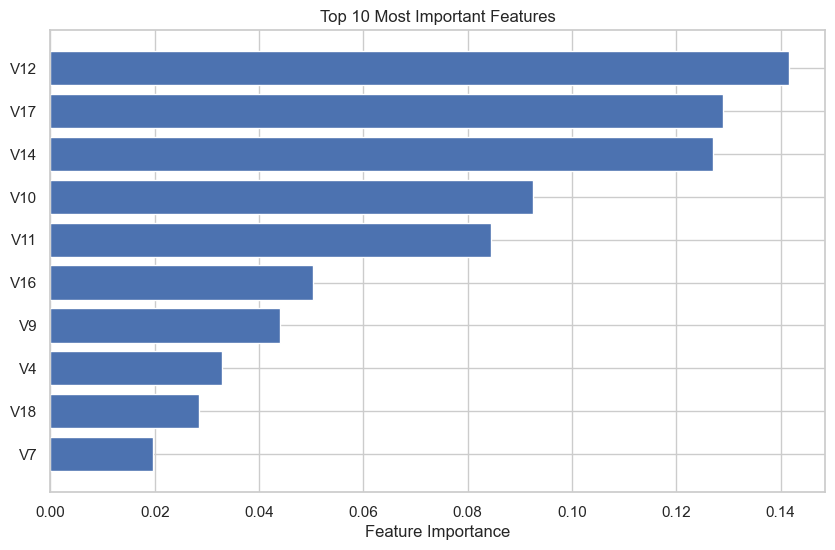

In [76]:
# visualize feature importances

plt.figure(figsize=(10,6))

plt.barh(
    feature_importance["Feature"][:10],
    feature_importance["Importance"][:10]
)

plt.gca().invert_yaxis()

plt.xlabel("Feature Importance")

plt.title("Top 10 Most Important Features")

plt.show()

## Feature Importance Interpretation

The Random Forest model identified several PCA-transformed variables, including **V12**, **V17**, and **V4**, as the most influential features for predicting fraudulent transactions.

Interestingly, transaction **Amount** and **Time** were not among the top ten most important features. This suggests that fraud detection in this dataset depends more on complex behavioural patterns captured by the PCA-transformed variables than on simple transaction characteristics.

Because the dataset is anonymized, the exact business meaning of the PCA variables cannot be determined. However, the results demonstrate that machine learning models can successfully identify complex interactions between variables that may not be apparent through manual analysis.

These findings further support the use of machine learning for fraud detection, as traditional rule-based systems relying only on variables such as transaction amount or transaction time may fail to capture the complexity of fraudulent behaviour.

In [77]:
%pip install shap

import shap




[notice] A new release of pip is available: 25.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


In [78]:
explainer = shap.TreeExplainer(random_forest)

# SHAP Explainability

While feature importance identifies the variables that are most influential across the entire model, SHAP (SHapley Additive exPlanations) explains how individual features contribute to each prediction.

SHAP provides local interpretability by showing whether a feature increases or decreases the probability that a transaction is classified as fraudulent.

This helps improve transparency and trust in machine learning models, particularly in high-stakes domains such as fraud detection.

In [79]:
# compute SHAP values for the test set
shap_values = explainer.shap_values(X_test)

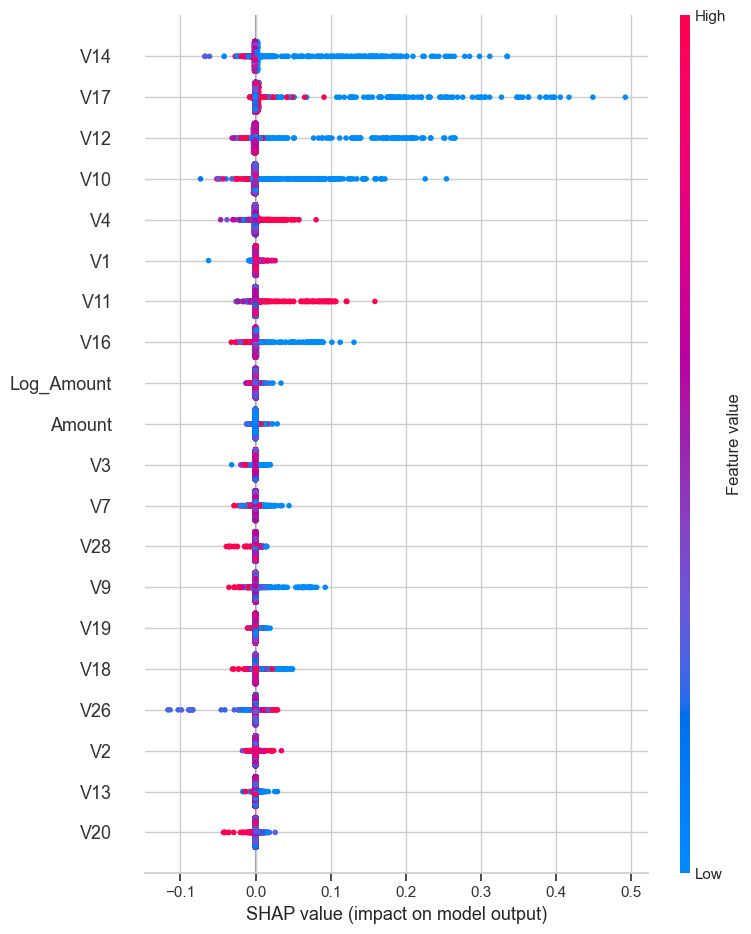

In [80]:
#shap summary plot for the positive class (fraudulent transactions)
shap.summary_plot(
    shap_values[:, :, 1],
    X_test
)

## SHAP Interpretation

The SHAP summary plot provides insight into both the importance and the direction of each feature's contribution.

Features such as **V14**, **V17**, and **V12** consistently have the largest influence on model predictions, confirming the results obtained from the feature importance analysis.

For example, lower values of **V14** tend to push predictions toward the fraud class, while higher values of **V11** tend to increase the likelihood of fraud. This demonstrates that SHAP not only identifies important variables but also explains how different feature values influence individual predictions.

Unlike traditional feature importance, SHAP provides local explanations for each prediction, making the model more transparent and easier to interpret for business stakeholders.

# Final Model Comparison

The three machine learning models were evaluated using multiple performance metrics to determine the most suitable model for fraud detection.

In [81]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "Accuracy":[
        0.9992,
        0.9992,
        0.9996
    ],

    "Precision":[
        0.83,
        0.76,
        0.95
    ],

    "Recall":[
        0.65,
        0.74,
        0.82
    ],

    "F1 Score":[
        0.73,
        0.75,
        0.88
    ],

    "ROC-AUC":[
        0.9599,
        0.8722,
        0.9528
    ]

})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.9992,0.83,0.65,0.73,0.9599
1,Decision Tree,0.9992,0.76,0.74,0.75,0.8722
2,Random Forest,0.9996,0.95,0.82,0.88,0.9528


## Model Comparison Interpretation

Although all three models achieved extremely high accuracy, accuracy alone was not sufficient because the dataset is highly imbalanced.

Random Forest achieved the highest balance between precision and recall, resulting in the highest F1-score while maintaining an excellent ROC-AUC score.

Logistic Regression performed well but missed more fraudulent transactions.

Decision Tree achieved better recall than Logistic Regression but suffered from lower precision and ROC-AUC.

Overall, Random Forest demonstrated the strongest balance between fraud detection capability and false positive control, making it the preferred model.

# Business Recommendations

Based on the analysis and modelling results, the following recommendations are proposed:

### Recommendation 1

Deploy the Random Forest model to support real-time fraud detection.

### Recommendation 2

Continue collecting fraud-related behavioural data to improve future model performance.

### Recommendation 3

Integrate machine learning into existing fraud monitoring systems to enable proactive detection rather than relying solely on manual investigation.

### Recommendation 4

Use model explanations such as SHAP to improve transparency and assist fraud analysts when reviewing flagged transactions.

### Recommendation 5

Continuously retrain the model using newly collected fraud cases to adapt to evolving fraud patterns.

# Part 3 — Deployment Considerations

## Deployment Considerations

Before deployment, several practical considerations should be addressed:

- Continuously monitor model performance after deployment.
- Retrain the model periodically using newly collected transaction data.
- Monitor precision and recall to detect performance degradation.
- Use SHAP explanations to improve model transparency.
- Ensure customer privacy and regulatory compliance when handling transaction data.
- Integrate the model into the bank's fraud monitoring workflow rather than replacing fraud analysts entirely.

# Part 4 — Project Conclusion

## Project Conclusion

This project successfully developed and evaluated multiple machine learning models for detecting fraudulent credit card transactions.

Three classification algorithms were compared:

- Logistic Regression
- Decision Tree
- Random Forest

Random Forest achieved the strongest balance between precision, recall, and F1-score while maintaining excellent overall performance.

Cross-validation confirmed that the model generalized well to unseen data, while hyperparameter tuning demonstrated only marginal improvements over the baseline model.

Feature Importance and SHAP analysis further improved model interpretability, providing both global and local explanations for fraud predictions.

Overall, the project demonstrates how machine learning can support proactive fraud detection by identifying complex behavioural patterns beyond traditional rule-based systems.